In [30]:
import pandas as pd
import numpy as np

fraud = pd.read_csv(r'C:\Users\Admin\Downloads\Datasets_For_Fraud_Detection.csv')
fraud.sample(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
68069,130,CASH_IN,319767.98,C329008714,10986.00,330753.98,C632624224,335968.11,16200.13,0,0
13643,15,TRANSFER,1183281.22,C184994918,0.00,0.00,C808904348,3768667.29,4951948.51,0,0
540669,16,CASH_IN,34369.27,C1165690214,922629.81,956999.08,C1873672823,377240.81,542628.95,0,0
267339,393,CASH_IN,137091.27,C331541654,256721.00,393812.27,C1665992976,16369.22,0.00,0,0
156246,253,CASH_OUT,291254.81,C224474695,83634.00,0.00,C263766417,25730.01,316984.81,0,0
315492,371,CASH_OUT,467465.00,C1256971060,0.00,0.00,C1982228761,916649.08,1384114.08,0,0
517114,155,CASH_OUT,396198.04,C758777799,409.00,0.00,C1097228741,64616.18,460814.21,0,0
629832,277,CASH_OUT,379730.79,C1283277018,0.00,0.00,C41859224,541337.47,921068.26,0,0
301688,355,PAYMENT,17829.58,C2029747355,34275.00,16445.42,M21541045,0.00,0.00,0,0
259425,131,PAYMENT,23015.44,C1775919705,238.00,0.00,M1181730204,0.00,0.00,0,0


## Handling Data Inconsistencies in the Dataset

During the exploratory phase, it was observed that a significant portion of the dataset contains transactions that do not follow logical financial rules. For example, some transactions show zero account balances while still allowing withdrawals, or inconsistencies between expected and actual balances after a transaction.

Despite these inconsistencies, the decision was made **not to remove these records** before training the model. This decision was based on the following considerations:

### 1. Preserving Data Volume

Approximately 63% of the dataset was identified as containing such inconsistencies. Removing these rows would result in a substantial loss of data, which could negatively impact the model’s ability to learn meaningful patterns.

### 2. Reflecting Real-World Scenarios

In real-world financial systems, data is often imperfect and may contain anomalies due to system errors, delays, or incomplete information. Retaining these records allows the model to be exposed to such irregularities, making it more robust and realistic.

### 3. Leveraging Feature Engineering

Instead of removing inconsistent data, a feature engineering approach was adopted. New variables such as `balance_error` and `is_logical` were created to explicitly capture these inconsistencies. This allows the model to learn from them rather than ignore them.

### 4. Avoiding Bias

Dropping a large portion of the dataset could introduce bias, especially if fraudulent transactions are disproportionately represented within the inconsistent records.

### Conclusion

Rather than discarding a large portion of the dataset, the approach taken was to retain all transactions and incorporate data quality indicators as features. This ensures that the model benefits from the full dataset while still accounting for inconsistencies in a structured and interpretable manner.


## Feature Engineering

Feature engineering was performed to create additional variables that better represent transaction behaviour.

The original dataset contains basic transaction details, but some important fraud patterns are not directly represented. Therefore, new features were created to capture balance inconsistencies and suspicious transaction behaviours.

The following features were added:

- `balance_error`: Measures the difference between the expected and actual new balance after a transaction.
- `is_full_drain`: Identifies transactions where the sender's account balance is completely emptied.
- `is_logical`: Indicates whether a transaction follows expected financial balance behaviour (1 = logical, 0 = not logical).

These engineered features provide additional information that can help machine learning models identify fraudulent transactions.

In [31]:
fraud['balance_error'] = (
    fraud['oldbalanceOrg'] 
    - fraud['amount'] 
    - fraud['newbalanceOrig']
)

fraud['is_full_drain'] = (
    fraud['newbalanceOrig'] == 0
).astype(int)

def check_logical(row):

    # Check sender balance consistency
    if abs((row['oldbalanceOrg'] - row['amount']) - row['newbalanceOrig']) > 1e-2:
        return 0

    # CASH_OUT without available balance
    if row['type'] == 'CASH_OUT' and row['oldbalanceOrg'] == 0:
        return 0

    # PAYMENT without sender balance
    if row['type'] == 'PAYMENT' and row['oldbalanceOrg'] == 0 and row['amount'] > 0:
        return 0

    return 1


fraud['is_logical'] = fraud.apply(check_logical, axis=1)

fraud.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_error,is_full_drain,is_logical
0,182,CASH_IN,100328.70,C197678862,3389602.37,3489931.07,C386191921,219735.14,119406.44,0,0,-200657.40,0,0
1,210,PAYMENT,11660.99,C2009511954,94054.00,82393.01,M564284134,0.00,0.00,0,0,0.00,0,1
2,403,CASH_IN,230751.30,C1132312861,23117012.10,23347763.39,C1025694734,951294.81,720543.51,0,0,-461502.59,0,0
3,328,PAYMENT,17833.60,C1191709365,0.00,0.00,M293024801,0.00,0.00,0,0,-17833.60,1,0
4,563,CASH_OUT,246476.67,C342438889,0.00,0.00,C2087488957,4226850.16,4473326.82,0,0,-246476.67,1,0


## Removing Unnecessary Features

Transaction identifiers (`nameOrig` and `nameDest`) were removed because they represent unique IDs rather than meaningful transaction behaviour.

The `isFlaggedFraud` feature was removed because it is an existing detection flag that could introduce bias into the model.

In [32]:
fraud = fraud.drop(
    columns=[
        'nameOrig',
        'nameDest',
        'isFlaggedFraud'
    ]
)

fraud.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balance_error,is_full_drain,is_logical
0,182,CASH_IN,100328.70,3389602.37,3489931.07,219735.14,119406.44,0,-200657.40,0,0
1,210,PAYMENT,11660.99,94054.00,82393.01,0.00,0.00,0,0.00,0,1
2,403,CASH_IN,230751.30,23117012.10,23347763.39,951294.81,720543.51,0,-461502.59,0,0
3,328,PAYMENT,17833.60,0.00,0.00,0.00,0.00,0,-17833.60,1,0
4,563,CASH_OUT,246476.67,0.00,0.00,4226850.16,4473326.82,0,-246476.67,1,0


## Encoding Categorical Variables

Machine learning algorithms require numerical inputs, therefore categorical variables must be converted into numerical representations.

The transaction type (`type`) contains categories such as CASH_OUT, TRANSFER, PAYMENT, and DEBIT. One-hot encoding was applied to convert these categories into binary numerical features while avoiding artificial ordering between categories.

In [33]:
# Encode categorical variable
fraud = pd.get_dummies(
    fraud,
    columns=['type'],
    drop_first=True
)

# Convert boolean columns to integers
bool_cols = fraud.select_dtypes(include='bool').columns
fraud[bool_cols] = fraud[bool_cols].astype(int)

fraud.dtypes

step                int64
amount            float64
oldbalanceOrg     float64
newbalanceOrig    float64
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
balance_error     float64
is_full_drain       int64
is_logical          int64
type_CASH_OUT       int64
type_DEBIT          int64
type_PAYMENT        int64
type_TRANSFER       int64
dtype: object

## Feature Importance Analysis

Random Forest was used to evaluate feature importance before model training.

This helps identify which variables contribute most to fraud detection and provides insight into the factors influencing fraudulent transactions.

In [34]:
from sklearn.ensemble import RandomForestClassifier

X = fraud.drop('isFraud', axis=1)
y = fraud['isFraud']


rf_feature = RandomForestClassifier(
    random_state=42
)

rf_feature.fit(X, y)


feature_importance = pd.Series(
    rf_feature.feature_importances_,
    index=X.columns
)

feature_importance.sort_values(
    ascending=False
)

is_full_drain     0.298199
newbalanceOrig    0.274427
balance_error     0.106796
is_logical        0.081295
amount            0.066979
newbalanceDest    0.057912
oldbalanceOrg     0.055356
step              0.026111
type_TRANSFER     0.012855
oldbalanceDest    0.010469
type_CASH_OUT     0.005680
type_PAYMENT      0.003917
type_DEBIT        0.000004
dtype: float64

In [35]:
fraud = fraud.drop(
    columns=[
        'type_DEBIT',
        'type_PAYMENT'
    ]
)

## Train-Test Split

The dataset was divided into training and testing sets to evaluate model performance on unseen data.

Stratified splitting was used because fraud detection datasets are highly imbalanced. This ensures that both training and testing sets maintain a similar proportion of fraudulent and non-fraudulent transactions.

In [36]:
fraud = fraud.sort_values(by='step')

X = fraud.drop('isFraud', axis=1)
y = fraud['isFraud']

split_index = int(len(fraud) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

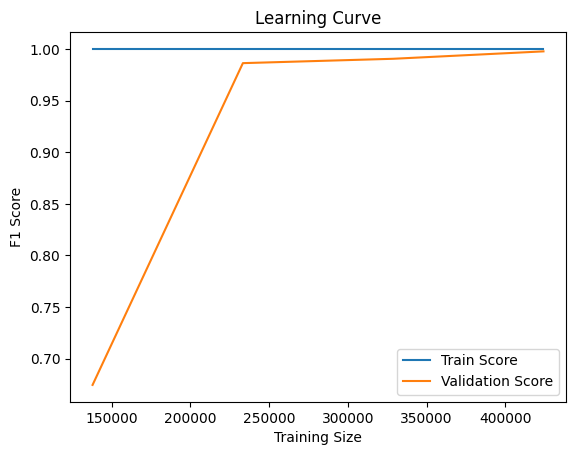

In [44]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X, y,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

## Random Forest Classification

Random Forest was used as a baseline model because it can handle complex relationships in structured transaction data. The model combines multiple decision trees to improve prediction performance and reduce overfitting.

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [38]:
from sklearn.metrics import confusion_matrix, classification_report

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Confusion Matrix:
[[126795      0]
 [     3    455]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    126795
           1       1.00      0.99      1.00       458

    accuracy                           1.00    127253
   macro avg       1.00      1.00      1.00    127253
weighted avg       1.00      1.00      1.00    127253



In [39]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring='f1'
)

print("Random Forest CV F1 scores:", rf_scores)
print("Random Forest Mean F1:", np.mean(rf_scores))

Random Forest CV F1 scores: [0.99109792 1.         1.         0.99705015 1.        ]
Random Forest Mean F1: 0.9976296140682581


## XGBoost Classification

XGBoost was selected as the final model because it is effective for structured datasets and can handle imbalanced classification problems by assigning more importance to the minority fraud class.

In [40]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(X_test)

In [41]:
print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nXGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost Confusion Matrix:
[[126795      0]
 [     0    458]]

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    126795
           1       1.00      1.00      1.00       458

    accuracy                           1.00    127253
   macro avg       1.00      1.00      1.00    127253
weighted avg       1.00      1.00      1.00    127253



In [42]:
xgb_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=cv,
    scoring='f1'
)

print("XGBoost CV F1 scores:", xgb_scores)
print("XGBoost Mean F1:", np.mean(xgb_scores))

XGBoost CV F1 scores: [0.99411765 0.99706745 1.         0.99705015 0.99706745]
XGBoost Mean F1: 0.9970605383824307


## Model Performance Observation

Both Random Forest and XGBoost achieved near-perfect performance on the test data. This is mainly due to the strong fraud patterns present in the dataset, where features such as balance changes, full account drainage, and transaction behaviour provide clear separation between fraudulent and non-fraudulent transactions.

The similar performance between the two models suggests that the dataset itself is highly predictable rather than the result being caused by model complexity. Although the results are strong, the dataset may not fully represent real-world fraud scenarios where fraudulent behaviour is usually more complex and difficult to distinguish.